In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [47]:
telco_data = pd.read_csv(r'D:\KAVERI\ML\Dataset\Cleaned_telco_customer_churn.csv', encoding='latin1')

In [48]:
telco_data.head()

,customerID,gender,contract,payment_method,monthly_charges,total_charges,tenure_months,churn_label,churn_value
0,3668-QPYBK,Male,Month-to-month,Mailed check,53.85,108.15,2,Yes,1
1,9237-HQITU,Female,Month-to-month,Electronic check,70.70,151.65,2,Yes,1
2,9305-CDSKC,Female,Month-to-month,Electronic check,99.65,820.5,8,Yes,1
3,7892-POOKP,Female,Month-to-month,Electronic check,104.80,3046.05,28,Yes,1
4,0280-XJGEX,Male,Month-to-month,Bank transfer (automatic),103.70,5036.3,49,Yes,1


In [49]:
telco_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   customerID       7043 non-null   str    
 1   gender           7043 non-null   str    
 2   contract         7043 non-null   str    
 3   payment_method   7043 non-null   str    
 4   monthly_charges  7043 non-null   float64
 5   total_charges    7043 non-null   str    
 6   tenure_months    7043 non-null   int64  
 7   churn_label      7043 non-null   str    
 8   churn_value      7043 non-null   int64  
dtypes: float64(1), int64(2), str(6)
memory usage: 495.3 KB


In [58]:
telco_data.isnull().sum()

customerID         0
gender             0
contract           0
payment_method     0
monthly_charges    0
total_charges      0
tenure_months      0
churn_label        0
churn_value        0
dtype: int64

In [51]:
telco_data.duplicated().sum()

np.int64(0)

In [52]:
telco_data.dtypes

customerID             str
gender                 str
contract               str
payment_method         str
monthly_charges    float64
total_charges          str
tenure_months        int64
churn_label            str
churn_value          int64
dtype: object

In [53]:
telco_data.shape

(7043, 9)

In [54]:
telco_data.columns

Index(['customerID', 'gender', 'contract', 'payment_method', 'monthly_charges',
       'total_charges', 'tenure_months', 'churn_label', 'churn_value'],
      dtype='str')

In [55]:
telco_data.describe()

,monthly_charges,tenure_months,churn_value
count,7043.000000,7043.000000,7043.000000
mean,64.761692,32.371149,0.265370
std,30.090047,24.559481,0.441561
min,18.250000,0.000000,0.000000
25%,35.500000,9.000000,0.000000
50%,70.350000,29.000000,0.000000
75%,89.850000,55.000000,1.000000
max,118.750000,72.000000,1.000000


In [59]:
telco_data['total_charges'] = pd.to_numeric(telco_data['total_charges'],  errors= 'coerce')

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

How many customers are churning?

In [64]:
telco_data['churn_label'].value_counts()

churn_label
No     5174
Yes    1869
Name: count, dtype: int64

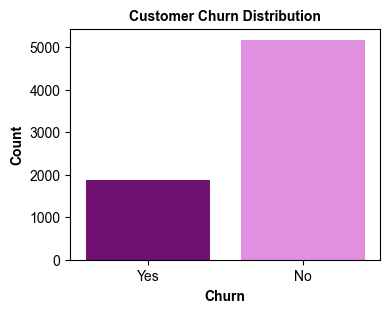

In [65]:
plt.figure(figsize= (4, 3))
palette = {
    "Yes" : "Purple",
     "No" : "Violet"
}
sns.countplot(x = "churn_label", data= telco_data, palette = palette, hue='churn_label', legend= False)


plt.title("Customer Churn Distribution",fontweight= "bold", fontsize = 10)
plt.xlabel("Churn", fontweight= "bold", fontsize = 10)
plt.ylabel("Count", fontweight= "bold", fontsize = 10)
sns.set_style("darkgrid")
plt.show()

In [66]:
telco_data['churn_label'].value_counts(normalize=True) * 100

churn_label
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

INSIGHT:

Most customers remained with the company, while approximately 26.5% customers churned.

In [67]:
telco_data['churn_value'].mean()

np.float64(0.2653698707936959)

In [69]:
pd.crosstab(telco_data['contract'], telco_data['churn_label'])

churn_label,No,Yes
contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


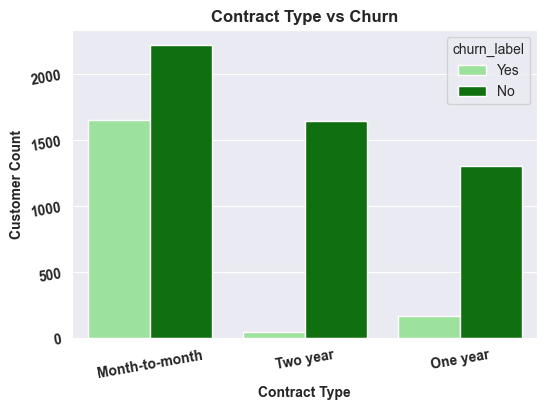

In [101]:
plt.figure(figsize=(6,4))
palette = {
    "Yes" : "lightgreen",
     "No" : "green"
}
sns.countplot(
    x="contract",
    data=telco_data,
    hue="churn_label",
    palette=palette, 
)

plt.title ('Contract Type vs Churn', fontweight = 'bold')
plt.xlabel('Contract Type', fontweight = "bold")
plt.ylabel ("Customer Count", fontweight = "bold")
plt.xticks(rotation = 10, fontweight = "bold")
plt.yticks(rotation = 10, fontweight = "bold")
plt.show()



In [57]:
telco_data.groupby('churn_label')['tenure_months'].mean()

churn_label
No     37.569965
Yes    17.979133
Name: tenure_months, dtype: float64

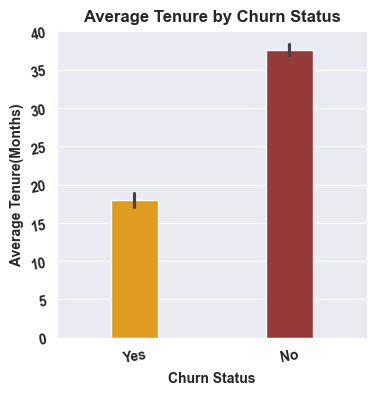

In [104]:
plt.figure(figsize=(4,4))
palette = {
    "Yes" : "orange",
     "No" : "brown"
}

sns.barplot(
    x='churn_label',
    y='tenure_months',
    data=telco_data,  
    hue="churn_label",
    palette=palette, width= 0.3
)

plt.title('Average Tenure by Churn Status', fontweight = "bold")
plt.xlabel('Churn Status', fontweight = "bold")
plt.ylabel ("Average Tenure(Months)", fontweight = "bold")
plt.xticks(rotation = 10, fontweight = "bold")
plt.yticks(rotation = 10, fontweight = "bold")
plt.show()

plt.show()

In [ ]:
telco_data.groupby('Churn Label')['Monthly Charges'].mean()

Churn Label
No     61.265124
Yes    74.441332
Name: Monthly Charges, dtype: float64

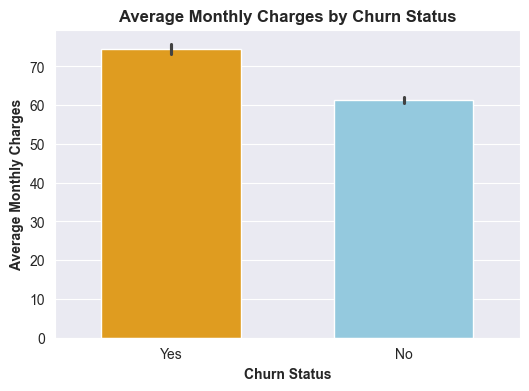

In [97]:
plt.figure(figsize=(6,4))

palette = {
    "Yes": "orange",
    "No": "skyblue"
}

sns.barplot(
    x='churn_label',
    y='monthly_charges',
    data=telco_data,
    hue= 'churn_label',
    palette=palette,
    width = 0.6
)

plt.title('Average Monthly Charges by Churn Status', fontweight = "bold")

plt.xlabel('Churn Status', fontweight = "bold")
plt.ylabel('Average Monthly Charges', fontweight = "bold")

plt.show()

In [ ]:
pd.crosstab(telco_data['Payment Method'], telco_data['Churn Label'])

Churn Label,No,Yes
Payment Method,,
Bank transfer (automatic),1286,258
Credit card (automatic),1290,232
Electronic check,1294,1071
Mailed check,1304,308


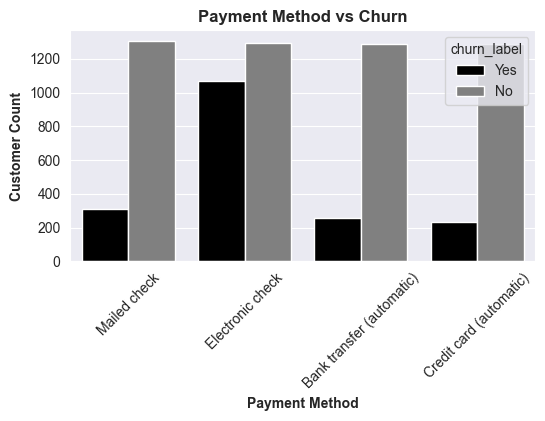

In [100]:
plt.figure(figsize=(6,3))

palette = {
    "Yes": "black",
    "No": "grey"
}

sns.countplot(
    x='payment_method',
    hue='churn_label',
    data=telco_data,
    palette=palette
)

plt.title('Payment Method vs Churn', fontweight='bold')

plt.xlabel('Payment Method', fontweight='bold')
plt.ylabel('Customer Count', fontweight='bold')

plt.xticks(rotation=45)

plt.show()